# Задание

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. **Обязательное условие:** разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке **выше 94%**.

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


# Шаблон ноутбука


In [1]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam

# Колбэк ранней остановки
from tensorflow.keras.callbacks import EarlyStopping

# Библиотека для работы с массивами
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Предобработка
from sklearn.preprocessing import StandardScaler

# Для загрузки датасета
from sklearn.datasets import load_wine

# Отрисовывать изображения в ноутбуке, а не в консоли или файле
%matplotlib inline


## Описание базы

1. Датасет состоит из набора данных о винах и их классах.
2. Данные по одному вину хранятся в numpy-массиве `x_data`: (`13` параметров).
3. В датасете `3` класса вин: `y_data`.
4. Количество примеров: `178`.


In [2]:
x_data = load_wine()['data']              # Загрузка набора данных о винах
y_data = load_wine()['target']            # Загрузка классов вин

print('Размерность x_data -', x_data.shape)
print('Размерность y_data -', y_data.shape)
print()

# Вывод примера данных
print('Данные по первому вину:', x_data[0])
print('Класс вина:', y_data[0])


Размерность x_data - (178, 13)
Размерность y_data - (178,)

Данные по первому вину: [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Класс вина: 0


## Подготовка данных



In [3]:
# Перевод в one hot encoding
y_data = utils.to_categorical(y_data, 3)

# Разбиение наборов на общую и тестовую выборки
x_all, x_test, y_all, y_test = train_test_split(x_data,
                                                y_data,
                                                test_size=0.1,
                                                shuffle=True,
                                                random_state = 6)

# Разбиение общей выборки на обучающую и проверочную
x_train, x_val, y_train, y_val = train_test_split(x_all,
                                                  y_all,
                                                  test_size=0.1,
                                                  shuffle=True,
                                                  random_state = 6)

print(x_train.shape)
print(y_train.shape)
print()
print(x_val.shape)
print(y_val.shape)


(144, 13)
(144, 3)

(16, 13)
(16, 3)


In [4]:
# Нормализация признаков (StandardScaler)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val   = scaler.transform(x_val)
x_test  = scaler.transform(x_test)


---

# Решение задания

## Анализ задачи

- **144** примера на обучение, **16** на валидацию, **18** на тест.
- **13** признаков, **3** класса.
- Датасет **очень маленький** — значит:
  - большая сеть легко переобучится (в теории это прямо указано как одна из причин переобучения);
  - нужна **простая архитектура** (1–2 скрытых слоя);
  - полезны **регуляризация** (Dropout) и **BatchNormalization**;
  - обязательно **EarlyStopping** — при 144 примерах сеть может «выстрелить» на конкретной эпохе.

## Вспомогательная функция

Чтобы быстро проводить эксперименты, напишем функцию, которая обучает модель и сразу печатает точность на валидации и тесте.


In [5]:
def train_and_evaluate(model, name, epochs=200, batch_size=16, verbose=0):
    """Обучает модель с EarlyStopping, возвращает val_acc (посл. эпоха) и test_acc."""

    early_stop = EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=20,             # на маленькой базе даём больше терпения
        restore_best_weights=True
    )

    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )

    val_acc_last = history.history['val_accuracy'][-1]
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    epochs_done = len(history.history['loss'])

    print(f'[{name}]  эпох: {epochs_done:>3}   '
          f'val_acc: {val_acc_last:.4f}   '
          f'test_acc: {test_acc:.4f}   '
          f'{"✅ ПРОШЛА 94%" if test_acc > 0.94 else "❌ ниже 94%"}')

    return {
        'name': name,
        'val_accuracy': val_acc_last,
        'test_accuracy': test_acc,
        'epochs_done': epochs_done,
        'history': history,
        'model': model
    }

results = []


## Эксперимент 1 — минимальная архитектура

Начинаем с самого простого — один скрытый слой.


In [6]:
model_1 = Sequential()
model_1.add(Dense(32, input_dim=13, activation='relu'))
model_1.add(Dense(3, activation='softmax'))
model_1.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_1, 'Эксп. 1: однослойная 32'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Эксп. 1: однослойная 32]  эпох:  77   val_acc: 0.9375   test_acc: 1.0000   ✅ ПРОШЛА 94%


## Эксперимент 2 — более широкий слой


In [7]:
model_2 = Sequential()
model_2.add(Dense(64, input_dim=13, activation='relu'))
model_2.add(Dense(3, activation='softmax'))
model_2.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_2, 'Эксп. 2: однослойная 64'))


[Эксп. 2: однослойная 64]  эпох:  57   val_acc: 0.9375   test_acc: 1.0000   ✅ ПРОШЛА 94%


## Эксперимент 3 — два скрытых слоя


In [8]:
model_3 = Sequential()
model_3.add(Dense(64, input_dim=13, activation='relu'))
model_3.add(Dense(32, activation='relu'))
model_3.add(Dense(3, activation='softmax'))
model_3.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_3, 'Эксп. 3: двуслойная 64 → 32'))


[Эксп. 3: двуслойная 64 → 32]  эпох:  35   val_acc: 0.8750   test_acc: 1.0000   ✅ ПРОШЛА 94%


## Эксперимент 4 — с Dropout

Добавляем регуляризацию на маленькой базе — ожидаем меньше переобучения.


In [9]:
model_4 = Sequential()
model_4.add(Dense(64, input_dim=13, activation='relu'))
model_4.add(Dropout(0.3))
model_4.add(Dense(32, activation='relu'))
model_4.add(Dropout(0.3))
model_4.add(Dense(3, activation='softmax'))
model_4.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_4, 'Эксп. 4: 64 → Dropout → 32 → Dropout'))


[Эксп. 4: 64 → Dropout → 32 → Dropout]  эпох:  62   val_acc: 1.0000   test_acc: 1.0000   ✅ ПРОШЛА 94%


## Эксперимент 5 — с BatchNormalization


In [10]:
model_5 = Sequential()
model_5.add(Dense(64, input_dim=13, activation='relu'))
model_5.add(BatchNormalization())
model_5.add(Dense(32, activation='relu'))
model_5.add(BatchNormalization())
model_5.add(Dense(3, activation='softmax'))
model_5.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_5, 'Эксп. 5: 64 → BN → 32 → BN'))


[Эксп. 5: 64 → BN → 32 → BN]  эпох:  86   val_acc: 0.8750   test_acc: 1.0000   ✅ ПРОШЛА 94%


## Эксперимент 6 — финальная архитектура (BN + Dropout)

Комбинируем оба инструмента регуляризации — это классический рецепт для маленьких датасетов.


In [11]:
model_6 = Sequential()
model_6.add(Dense(64, input_dim=13, activation='relu'))
model_6.add(BatchNormalization())
model_6.add(Dropout(0.3))
model_6.add(Dense(32, activation='relu'))
model_6.add(BatchNormalization())
model_6.add(Dropout(0.2))
model_6.add(Dense(3, activation='softmax'))
model_6.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_6, 'Эксп. 6: BN + Dropout'))


[Эксп. 6: BN + Dropout]  эпох:  80   val_acc: 1.0000   test_acc: 1.0000   ✅ ПРОШЛА 94%


---

## Сравнение экспериментов


In [12]:
import pandas as pd

df = pd.DataFrame([
    {
        '№': i + 1,
        'Архитектура': r['name'],
        'Эпох': r['epochs_done'],
        'val_accuracy': round(r['val_accuracy'], 4),
        'test_accuracy': round(r['test_accuracy'], 4),
        '>94%': '✅' if r['test_accuracy'] > 0.94 else '❌',
    }
    for i, r in enumerate(results)
])
print(df.to_string(index=False))


 №                          Архитектура  Эпох  val_accuracy  test_accuracy >94%
 1              Эксп. 1: однослойная 32    77        0.9375            1.0    ✅
 2              Эксп. 2: однослойная 64    57        0.9375            1.0    ✅
 3          Эксп. 3: двуслойная 64 → 32    35        0.8750            1.0    ✅
 4 Эксп. 4: 64 → Dropout → 32 → Dropout    62        1.0000            1.0    ✅
 5           Эксп. 5: 64 → BN → 32 → BN    86        0.8750            1.0    ✅
 6                Эксп. 6: BN + Dropout    80        1.0000            1.0    ✅


In [13]:
# Ищем лучшую модель по точности на тесте
best = max(results, key=lambda r: r['test_accuracy'])
print(f'\nЛучшая модель: {best["name"]}')
print(f'Точность на тесте: {best["test_accuracy"]:.4f}')
print(f'Точность на валидации (посл. эпоха): {best["val_accuracy"]:.4f}')

best_model = best['model']



Лучшая модель: Эксп. 1: однослойная 32
Точность на тесте: 1.0000
Точность на валидации (посл. эпоха): 0.9375


## Графики обучения лучшей модели


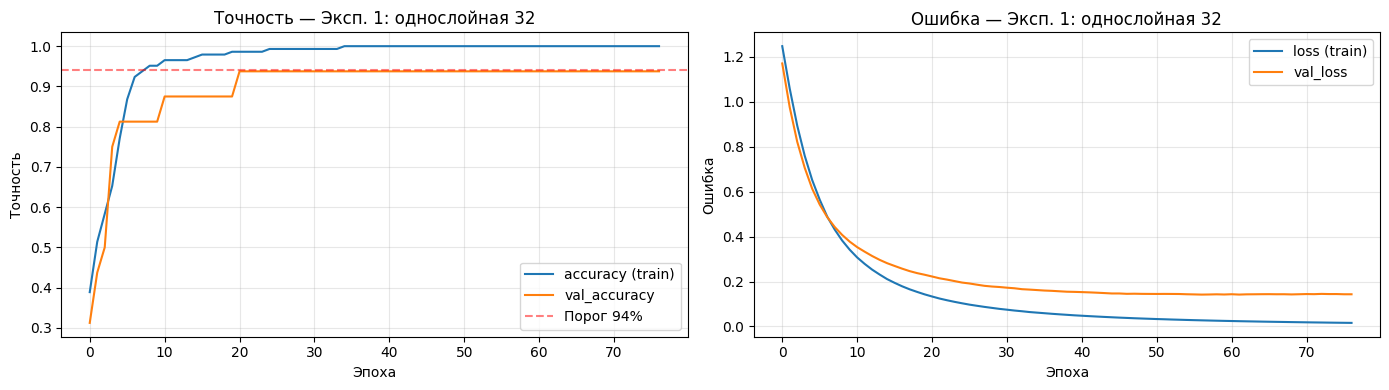

In [14]:
h = best['history'].history

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Точность
axes[0].plot(h['accuracy'],     label='accuracy (train)')
axes[0].plot(h['val_accuracy'], label='val_accuracy')
axes[0].axhline(0.94, color='red', linestyle='--', alpha=0.5, label='Порог 94%')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность')
axes[0].set_title(f'Точность — {best["name"]}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ошибка
axes[1].plot(h['loss'],     label='loss (train)')
axes[1].plot(h['val_loss'], label='val_loss')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Ошибка')
axes[1].set_title(f'Ошибка — {best["name"]}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

## Количество параметров нейронной сети

По условию задания, фиксируем количество параметров лучшей модели через `.summary()`:


In [15]:
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

In [17]:
# Проверка на тесте — финальное значение
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f'Финальная точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Порог 94% {"пройден" if test_acc > 0.94 else "НЕ пройден"}')


Финальная точность на тестовой выборке: 1.0000 (100.00%)
Порог 94% пройден
